# Checkpoint 1: Data Loading, Preview, and Target Leakage Analysis

We load the dataset to examine its shape, column data types, missing values, and duplicate records. Additionally, we verify that there are no post-event administrative features that leak the target outcome.

In [1]:
import pandas as pd

df = pd.read_csv('titanic.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373

# Checkpoint 2: Handling Null Values with a Per-Column Reasoned Strategy

We analyze the missing data mechanisms rather than discarding rows. The 'Embarked' column (MCAR) is filled using its mode. The 'Age' column (MAR) is handled using the median grouped by passenger class (Pclass) and sex to preserve demographic distributions. The 'Cabin' column (MNAR) is preserved by setting missing values to a distinct 'Unknown' category to retain the physical signal.

In [2]:
# 1. Fill missing Embarked values with the most common port (Mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Fill missing Ages using the median age of passengers of the same Pclass and Sex
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# 3. Fill missing Cabin entries with 'Unknown' to keep the column signal
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Print out the missing values count to confirm everything is clean
print("Missing values per column after cleaning:")
print(df.isnull().sum())

Missing values per column after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# Checkpoint 3: Outlier Detection and Processing

We utilize the Interquartile Range (IQR) method for outlier detection. The IQR method is chosen over the Z-score because our primary numerical features—particularly 'Fare'—are heavily right-skewed and do not follow a normal distribution. We identify outliers outside of the bounds $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$. Instead of dropping outlier rows (which would eliminate critical information about wealthy passengers or unique demographics), we apply a capping strategy (winsorization) to the upper and lower boundaries to robustly manage extreme values without shrinking the dataset.

In [3]:
import numpy as np

# Select numerical columns for outlier inspection
numerical_cols = ['Age', 'Fare']

print("Outlier Capping Summary:")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many outliers exist before capping
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f" - {col}: Found {outliers} outliers. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    
    # Cap the outliers (Winsorization)
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print("\nOutlier processing complete. Check a summary of the data distribution:")
print(df[numerical_cols].describe())

Outlier Capping Summary:
 - Age: Found 33 outliers. Lower bound: -0.25, Upper bound: 57.75
 - Fare: Found 116 outliers. Lower bound: -26.72, Upper bound: 65.63

Outlier processing complete. Check a summary of the data distribution:
              Age        Fare
count  891.000000  891.000000
mean    28.893850   24.046813
std     12.732352   20.481625
min      0.420000    0.000000
25%     21.500000    7.910400
50%     26.000000   14.454200
75%     36.000000   31.000000
max     57.750000   65.634400


# Checkpoint 4: Feature Engineering

We engineer two new columns to extract hidden behavioral patterns and improve the predictive potential of the dataset:
1. **'FamilySize'**: Combines horizontal family ties ('SibSp') and vertical family ties ('Parch') plus the passenger themselves ($1$). This captures the structural impact of traveling with family.
2. **'IsAlone'**: A binary indicator variable ($1$ for true, $0$ for false) derived directly from 'FamilySize' to clearly isolate and contrast individual solo travelers against groups.

In [4]:
# 1. Create FamilySize column
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Create IsAlone column (1 if FamilySize is 1, else 0)
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Preview the newly created features
print("Preview of the engineered columns:")
print(df[['Name', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']].head())

print("\nDistribution of Solo Travelers vs Families:")
print(df['IsAlone'].value_counts())

Preview of the engineered columns:
                                                Name  SibSp  Parch  \
0                            Braund, Mr. Owen Harris      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      1      0   
2                             Heikkinen, Miss. Laina      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      1      0   
4                           Allen, Mr. William Henry      0      0   

   FamilySize  IsAlone  
0           2        0  
1           2        0  
2           1        1  
3           2        0  
4           1        1  

Distribution of Solo Travelers vs Families:
IsAlone
1    537
0    354
Name: count, dtype: int64


# Checkpoint 5: Exploratory Data Visualization

We generate diagnostic visualizations to expose statistical patterns, relationships, and structural properties within the engineered dataset:
1. **Distribution Plots**: Inspecting the distribution profiles of numerical fields ('Age' and 'Fare').
2. **Correlation Heatmap**: Analyzing linear trends and multi-collinearity across numerical variables.
3. **Categorical Breakdown**: Evaluating how key categories like 'Sex', 'Pclass', and our engineered 'IsAlone' variable correlate directly with survival status.

C:\Users\User\AppData\Local\Temp\ipykernel_7956\775153662.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', ax=axes[1, 0], palette='muted', errorbar=None)
C:\Users\User\AppData\Local\Temp\ipykernel_7956\775153662.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='IsAlone', y='Survived', ax=axes[1, 1], palette='pastel', errorbar=None)


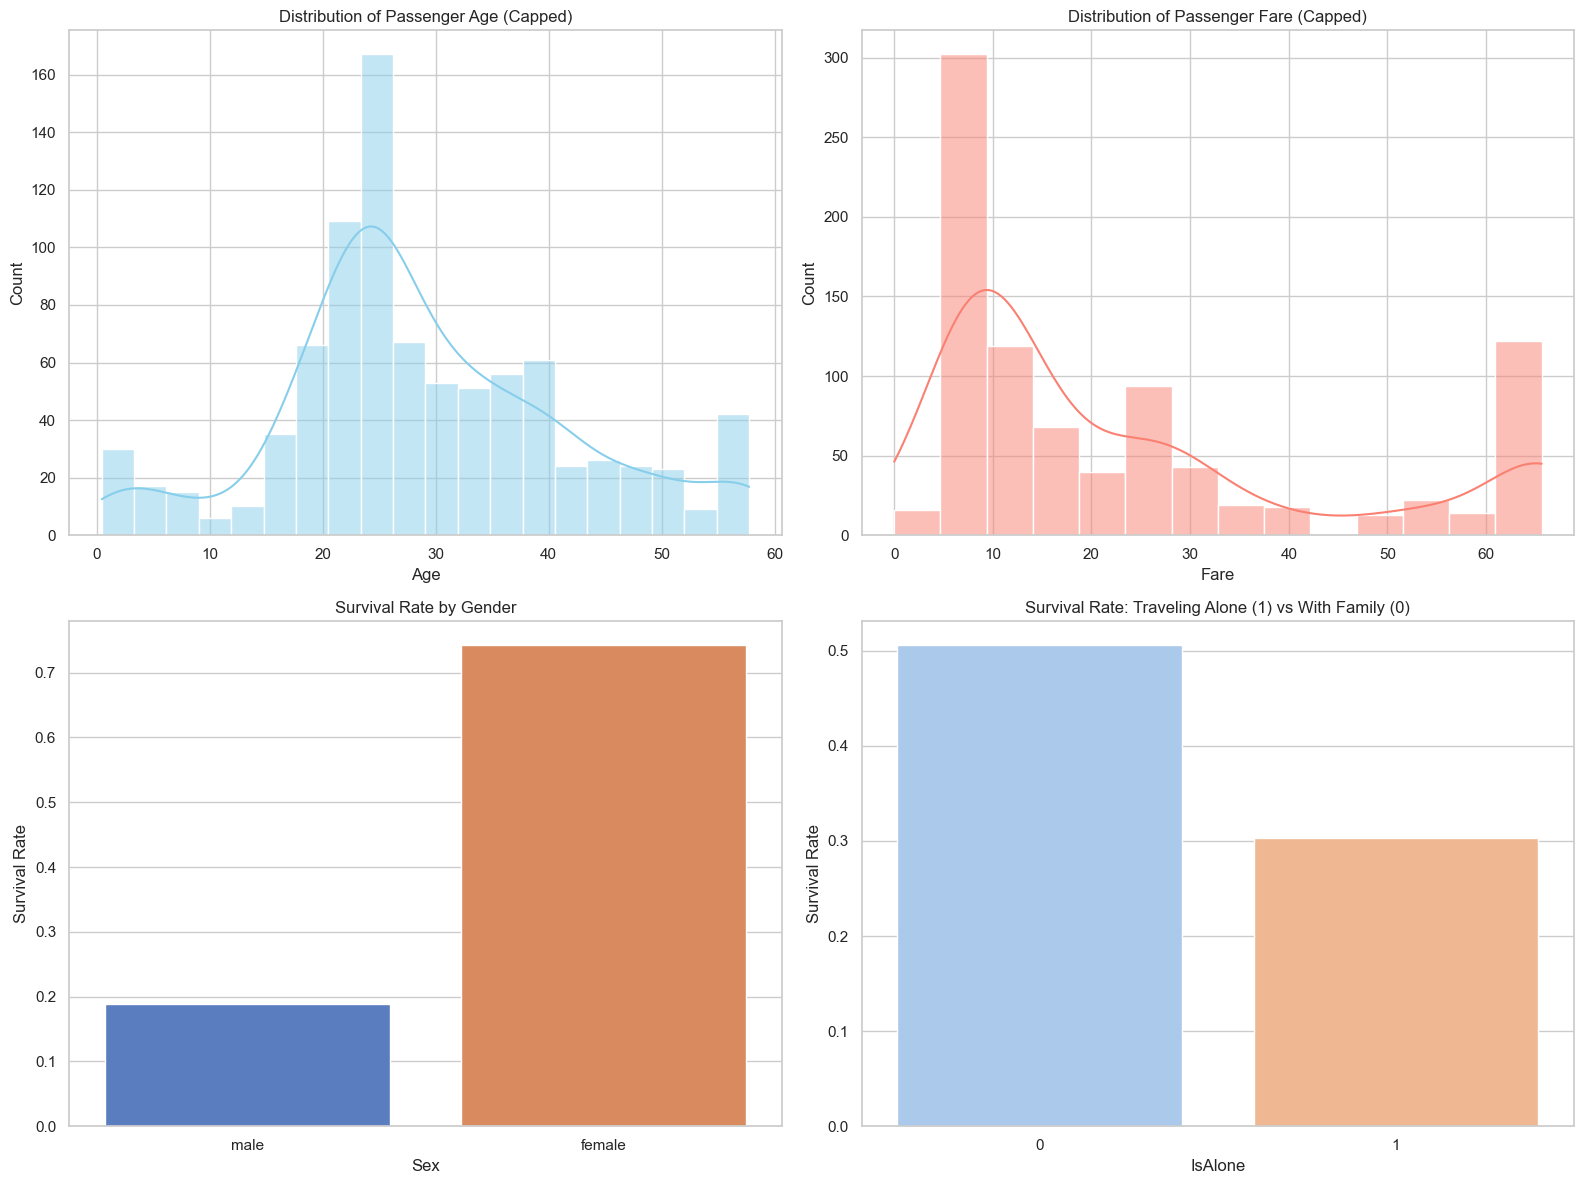

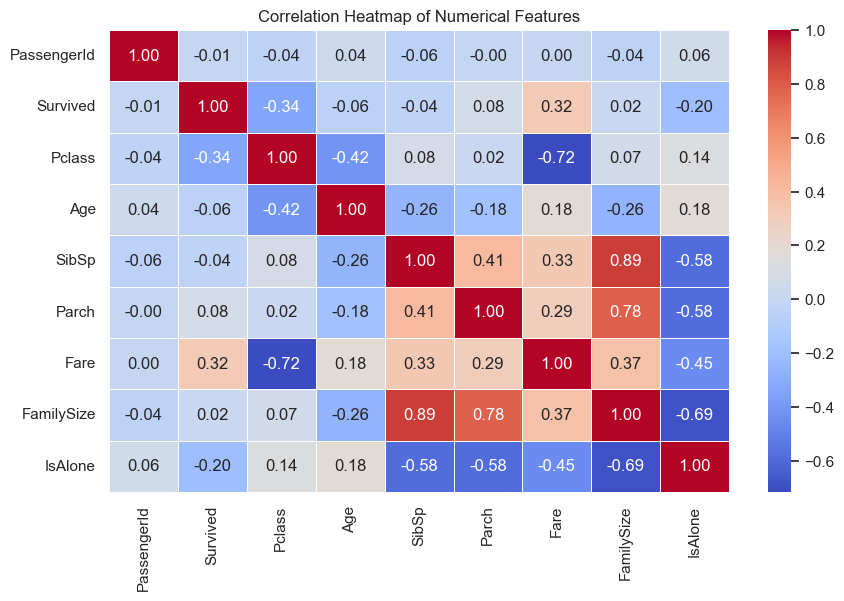

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution Graph for Age
sns.histplot(data=df, x='Age', kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Passenger Age (Capped)')

# 2. Distribution Graph for Fare
sns.histplot(data=df, x='Fare', kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Passenger Fare (Capped)')

# 3. Categorical Breakdown: Survival by Sex
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[1, 0], palette='muted', errorbar=None)
axes[1, 0].set_title('Survival Rate by Gender')
axes[1, 0].set_ylabel('Survival Rate')

# 4. Categorical Breakdown: Survival by Engineered 'IsAlone' Feature
sns.barplot(data=df, x='IsAlone', y='Survived', ax=axes[1, 1], palette='pastel', errorbar=None)
axes[1, 1].set_title('Survival Rate: Traveling Alone (1) vs With Family (0)')
axes[1, 1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# 5. Standalone Correlation Heatmap
plt.figure(figsize=(10, 6))
# Select only numeric columns for the correlation matrix calculation
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()